# Event Images Visualization & Fine-Tuning Notebook
這份 Jupyter Notebook 專為 **全事件圖像 (Event Images)** 與 **1D $\eta$-projection Profiles** 的細緻互動調整而設計。

### 本次樣式規範更新：
1. **單位標註**：全面採用中括號，例如 `[GeV]`（取代 `(GeV)`）。
2. **物理下標正體化**：橫向動量與橫向能量標記為 $p_{\mathrm{T}}$ 與 $E_{\mathrm{T}}$（下標 $\mathrm{T}$ 為正體）。
3. **圖例樣式**：所有曲線圖例無外邊框 (`frameon=False`)，風格乾淨俐落。

### 功能模組：
- **Cell 1**: 套件匯入與 Matplotlib 論文級繪圖參數設定
- **Cell 2**: 載入快取資料 (`cached_event_images.npz`) 或 Parquet
- **Cell 3**: 單事件白底高對比度可視化與個別 PDF 匯出
- **Cell 4**: EW 訊號 vs. 背景 (QCD) 平均沉積熱圖互動微調
- **Cell 5**: 極化態 (LL, LT, TT) 平均熱圖與差分圖 (LL - TT) 微調
- **Cell 6**: 1D $\eta$-projection Profiles (Figure 20) 曲線樣式、顏色、線型與圖例細緻微調

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# 設定高能物理 (HEP) 出版級繪圖樣式
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': False,      # 圖例預設無邊框
    'figure.autolayout': True,
})

# 設定工作路徑與輸出目錄
WORKSPACE_ROOT = Path("..").resolve() if Path("..").resolve().name == "longitudinal_W" else Path(".").resolve()
FIG_DIR = WORKSPACE_ROOT / "figures" / "event_images"
PDF_DIR = FIG_DIR / "pdf"
PDF_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = FIG_DIR / "cached_event_images.npz"

print(f"工作目錄: {WORKSPACE_ROOT}")
print(f"PDF 輸出目錄: {PDF_DIR}")
print(f"快取檔案路徑: {CACHE_FILE}")

工作目錄: /Users/fengyang/longitudinal_W
PDF 輸出目錄: /Users/fengyang/longitudinal_W/figures/event_images/pdf
快取檔案路徑: /Users/fengyang/longitudinal_W/figures/event_images/cached_event_images.npz


## 1. 載入影像數據 (Fast Cache Loading)
預設直接從 `figures/event_images/cached_event_images.npz` 讀取已統計好的 140k / 200k 事件平均影像矩陣與 $\eta$ bins，秒級完成載入。

In [2]:
# 載入快取數據
if CACHE_FILE.exists():
    print(f"載入快取數據: {CACHE_FILE}")
    cache_data = np.load(CACHE_FILE)
    bins_eta = cache_data["bins_eta"]
    avg_images = {k: cache_data[k] for k in cache_data.files if k != "bins_eta"}
    print(f"成功載入進程: {list(avg_images.keys())}")
    for k, v in avg_images.items():
        print(f"  {k:15s}: shape = {v.shape} (通道數, H, W)")
else:
    print(f"快取檔案不存在: {CACHE_FILE}")
    print("請先在集群執行 CNN/plot_event_images.py 或提交 PBS job 生成快取！")

載入快取數據: /Users/fengyang/longitudinal_W/figures/event_images/cached_event_images.npz
成功載入進程: ['EW_Signal', 'QCD_Background', 'Pol_LL', 'Pol_LT', 'Pol_TT']
  EW_Signal      : shape = (4, 40, 40) (通道數, H, W)
  QCD_Background : shape = (4, 40, 40) (通道數, H, W)
  Pol_LL         : shape = (4, 40, 40) (通道數, H, W)
  Pol_LT         : shape = (4, 40, 40) (通道數, H, W)
  Pol_TT         : shape = (4, 40, 40) (通道數, H, W)


## 2. 單事件圖像 (Single Event Gallery) 細緻微調
提供高對比、白色背景的自訂漸層色階（白 $\to$ 飽和色 $\to$ 深色），避免全黑背景在論文印刷與閱讀時造成的反差疲勞。

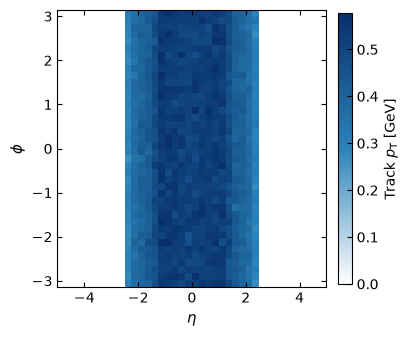

In [3]:
def make_white_cmap(color_hex_mid: str, color_hex_dark: str, name: str):
    """建立以純白 (0.0) 開始的平滑漸層 Colormap"""
    return LinearSegmentedColormap.from_list(name, ["#ffffff", color_hex_mid, color_hex_dark])

cmap_trk = make_white_cmap("#2b83ba", "#08306b", "white_blue")
cmap_pho = make_white_cmap("#4dac26", "#00441b", "white_green")
cmap_had = make_white_cmap("#fdae61", "#a63603", "white_orange")
cmap_tot = make_white_cmap("#9970ab", "#40004b", "white_purple")

def plot_single_heatmap(
    data: np.ndarray,
    cmap,
    cbar_label: str,
    vmax: float = None,
    output_pdf: str = None,
    figsize: tuple = (4.2, 3.5),
):
    fig, ax = plt.subplots(figsize=figsize)
    if vmax is None:
        vmax = max(np.percentile(data[data > 0], 99.5), 1e-2) if np.any(data > 0) else 1.0

    im = ax.imshow(
        data.T,
        origin="lower",
        extent=[-5.0, 5.0, -np.pi, np.pi],
        cmap=cmap,
        vmin=0.0,
        vmax=vmax,
        aspect="auto",
    )
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=10)
    ax.set_xlabel(r"$\eta$", fontsize=11)
    ax.set_ylabel(r"$\phi$", fontsize=11)
    plt.tight_layout()
    if output_pdf:
        plt.savefig(output_pdf, bbox_inches="tight")
        print(f"已儲存: {output_pdf}")
    plt.show()

# 測試單事件熱圖繪製 (若有快取可用平均影像第一通道展示效果)
if "EW_Signal" in avg_images:
    sample_data = avg_images["EW_Signal"][0]  # Track channel
    plot_single_heatmap(
        sample_data,
        cmap=cmap_trk,
        cbar_label=r"Track $p_{\mathrm{T}}$ [GeV]",
        output_pdf=None # 設為路徑即可匯出 PDF，例如: PDF_DIR / "test_single_track.pdf"
    )

## 3. EW 訊號 vs. 背景 (QCD) 平均熱圖微調
微調 140,000 事件統計平均下的三通道分佈。
- 可調整 `vmax` 以保持訊號與背景在相同通道使用一致的色階範圍。
- 單位為 `[GeV]`，下標為正體 $p_{\mathrm{T}}$, $E_{\mathrm{T}}$。

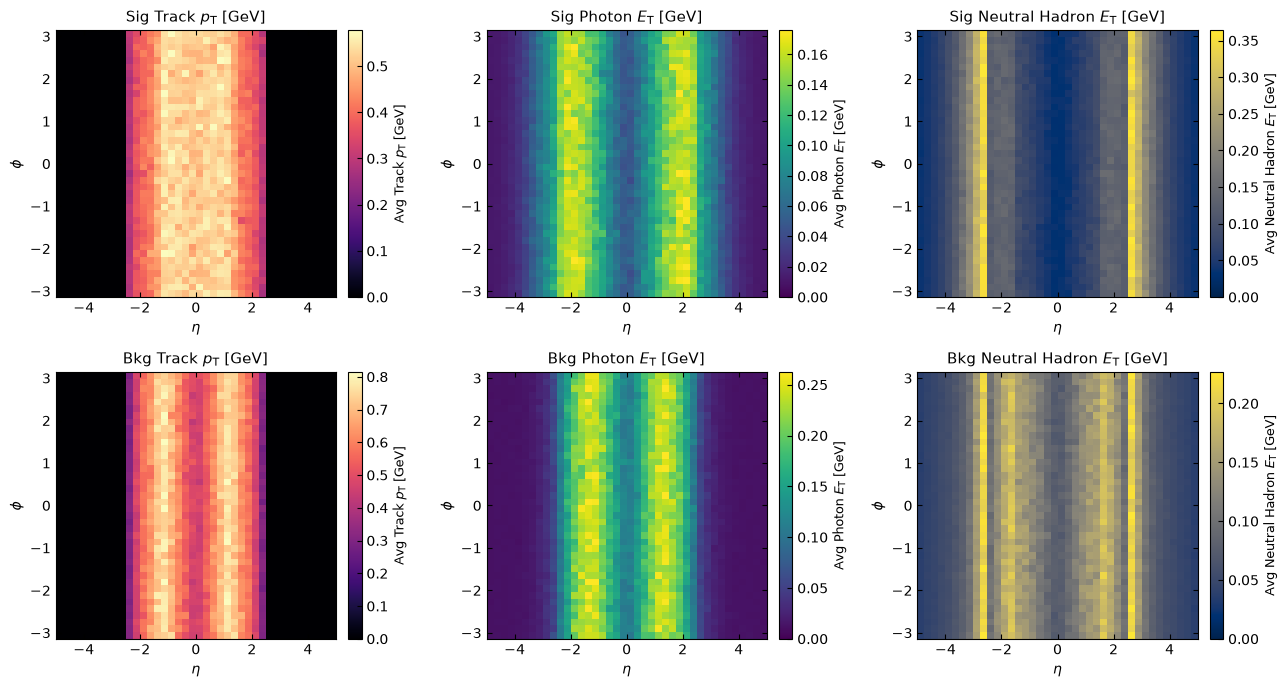

In [4]:
cmaps = ["magma", "viridis", "cividis"]
cbar_labels = [
    r"Avg Track $p_{\mathrm{T}}$ [GeV]",
    r"Avg Photon $E_{\mathrm{T}}$ [GeV]",
    r"Avg Neutral Hadron $E_{\mathrm{T}}$ [GeV]",
]
channel_keys = ["track", "photon", "hadron"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
processes = [("EW_Signal", "Sig", 0), ("QCD_Background", "Bkg", 1)]

for proc_key, proc_label, row_idx in processes:
    if proc_key not in avg_images:
        continue
    img_3ch = avg_images[proc_key][:3]
    for c in range(3):
        ax = axes[row_idx, c]
        data = img_3ch[c]
        vmax = np.percentile(data[data > 0], 99.5) if np.any(data > 0) else 1.0
        im = ax.imshow(
            data.T,
            origin="lower",
            extent=[-5.0, 5.0, -np.pi, np.pi],
            cmap=cmaps[c],
            vmin=0.0,
            vmax=vmax,
            aspect="auto",
        )
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_labels[c], fontsize=9)
        ax.set_title(f"{proc_label} {cbar_labels[c].replace('Avg ', '')}", fontsize=11)
        ax.set_xlabel(r"$\eta$", fontsize=10)
        ax.set_ylabel(r"$\phi$", fontsize=10)

plt.tight_layout()
plt.show()

# 一鍵匯出所有 6 張獨立 PDF
def export_ew_vs_qcd_pdfs():
    for proc_key, prefix in [("EW_Signal", "ew_140k"), ("QCD_Background", "qcd_140k")]:
        for c in range(3):
            out_path = PDF_DIR / f"{prefix}_{channel_keys[c]}.pdf"
            plot_single_heatmap(
                avg_images[proc_key][c],
                cmap=cmaps[c],
                cbar_label=cbar_labels[c],
                output_pdf=str(out_path)
            )

# 若要重新產生並覆蓋 PDF，解除下行註解執行：
# export_ew_vs_qcd_pdfs()

## 4. 極化態 (LL, LT, TT) 平均熱圖與差分圖微調
微調 200,000 事件統計下的極化態圖像，以及 $\Delta(\text{LL} - \text{TT})$ 差分圖。
- 差分圖採用對稱發散色階 `bwr`，中心點為 0。

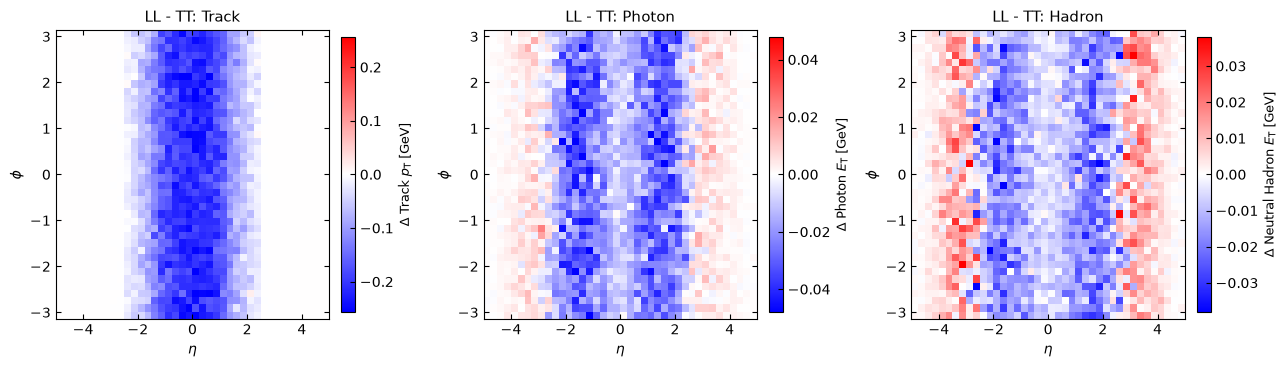

In [5]:
diff_img = avg_images["Pol_LL"] - avg_images["Pol_TT"]
diff_labels = [
    r"$\Delta$ Track $p_{\mathrm{T}}$ [GeV]",
    r"$\Delta$ Photon $E_{\mathrm{T}}$ [GeV]",
    r"$\Delta$ Neutral Hadron $E_{\mathrm{T}}$ [GeV]",
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for c in range(3):
    ax = axes[c]
    data = diff_img[c]
    abs_max = max(np.percentile(np.abs(data), 99.5), 1e-3)
    im = ax.imshow(
        data.T,
        origin="lower",
        extent=[-5.0, 5.0, -np.pi, np.pi],
        cmap="bwr",
        vmin=-abs_max,
        vmax=abs_max,
        aspect="auto",
    )
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(diff_labels[c], fontsize=9)
    ax.set_title(f"LL - TT: {channel_keys[c].capitalize()}", fontsize=11)
    ax.set_xlabel(r"$\eta$", fontsize=10)
    ax.set_ylabel(r"$\phi$", fontsize=10)

plt.tight_layout()
plt.show()

## 5. 1D $\eta$-projection Profiles (Figure 20) 核心細緻微調
對應筆記中的 Figure 20，比較 LL ($W_L W_L$)、LT ($W_L W_T$) 與 TT ($W_T W_T$) 三種極化狀態在不同通道上的能量沉積曲線。

### 可調整參數：
- **曲線顏色與線型**：
  - LL: 鮮明紅色 (`#d7191c`)、實線 (`-`)
  - LT: 墨綠色 (`#2ca25f`)、虛線 (`--`)
  - TT: 經典藍色 (`#2b83ba`)、點線 (`:`)
- **圖例無框線**：`ax.legend(frameon=False, fontsize=9, loc='upper right')`
- **軸標籤與單位**：`Total Deposited Track $p_{\mathrm{T}}$ [GeV]`
- **線寬與網格透明度**：可手動調整 `lw` 與 `alpha`
- **匯出**：直接更新覆蓋 `figures/event_images/pdf/profile_200k_*.pdf`

--- 繪製通道: track ---
已儲存向量 PDF: /Users/fengyang/longitudinal_W/figures/event_images/pdf/profile_200k_track.pdf


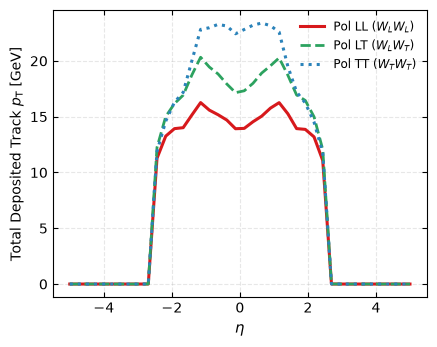

--- 繪製通道: photon ---
已儲存向量 PDF: /Users/fengyang/longitudinal_W/figures/event_images/pdf/profile_200k_photon.pdf


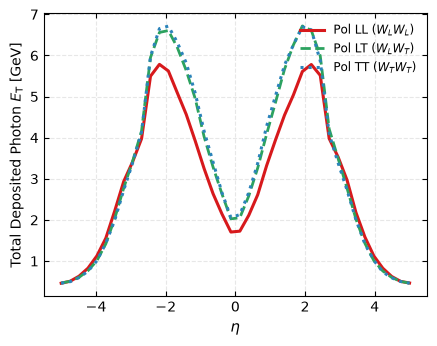

--- 繪製通道: hadron ---
已儲存向量 PDF: /Users/fengyang/longitudinal_W/figures/event_images/pdf/profile_200k_hadron.pdf


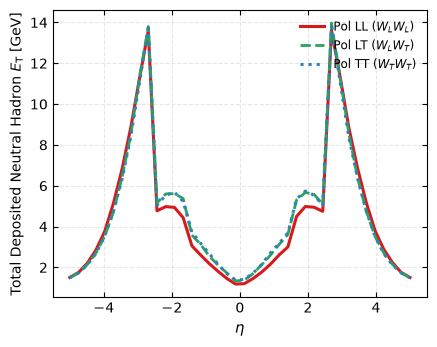

In [6]:
# 定義極化態顯示名稱、顏色與線條風格
pol_configs = {
    "Pol_LL": {"label": r"Pol LL ($W_L W_L$)", "color": "#d7191c", "linestyle": "-", "lw": 2.2},
    "Pol_LT": {"label": r"Pol LT ($W_L W_T$)", "color": "#2ca25f", "linestyle": "--", "lw": 2.0},
    "Pol_TT": {"label": r"Pol TT ($W_T W_T$)", "color": "#2b83ba", "linestyle": ":", "lw": 2.2},
}

profile_ylabels = [
    r"Total Deposited Track $p_{\mathrm{T}}$ [GeV]",
    r"Total Deposited Photon $E_{\mathrm{T}}$ [GeV]",
    r"Total Deposited Neutral Hadron $E_{\mathrm{T}}$ [GeV]",
]

def plot_and_export_profiles(channel_idx: int, save_pdf: bool = True):
    """繪製並匯出單一通道的 1D eta-projection profile"""
    fig, ax = plt.subplots(figsize=(4.5, 3.6))
    
    for proc_key, cfg in pol_configs.items():
        if proc_key not in avg_images:
            continue
        # 沿 phi 軸 (axis 1) 積分求和: shape (40,)
        prof_1d = np.sum(avg_images[proc_key][channel_idx], axis=1)
        ax.plot(
            bins_eta,
            prof_1d,
            label=cfg["label"],
            color=cfg["color"],
            linestyle=cfg["linestyle"],
            linewidth=cfg["lw"],
        )
    
    ax.set_xlabel(r"$\eta$", fontsize=11)
    ax.set_ylabel(profile_ylabels[channel_idx], fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    # 圖例：無外邊框 frameon=False，字型大小可微調
    ax.legend(frameon=False, fontsize=8.5, loc="upper right")
    
    plt.tight_layout()
    
    if save_pdf:
        out_pdf = PDF_DIR / f"profile_200k_{channel_keys[channel_idx]}.pdf"
        plt.savefig(out_pdf, bbox_inches="tight")
        print(f"已儲存向量 PDF: {out_pdf}")
        
    plt.show()

# 互動預覽並匯出三個通道的 Profiles
for c in range(3):
    print(f"--- 繪製通道: {channel_keys[c]} ---")
    plot_and_export_profiles(channel_idx=c, save_pdf=True)